# Cleaned pie-chart generator

This version removes old/dead code, makes the Excel sheet the style schema source, and adds parameters for the missing options.

In [1]:
#from __future__ import annotations

import json
import shutil
from datetime import datetime
from pathlib import Path
from uuid import uuid4

import altair as alt
import kaleido
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except Exception:
    sns = None
import plotly.express as px
import vl_convert

In [ ]:
from pathlib import Path

# Project paths
PROJECT = Path.cwd().resolve()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent

DATA_RAW = PROJECT / "data" / "raw"
DATA_PROCESSED = PROJECT / "data" / "processed"
DATA_TRAIN = PROJECT / "data" / "train"

# Normal generated outputs
OUT_ROOT = PROJECT / "outputs" / "generated" / "pieplots"

# Testing outputs
PIE_TESTING_ROOT = PROJECT / "testing" / "pie_testing"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
PIE_TESTING_ROOT.mkdir(parents=True, exist_ok=True)

CLEAR_OUTPUT = True

LIBRARIES = ["altair", "matplotlib", "seaborn", "plotly"]
SUBDIRS = ["images", "tables", "meta"]

# Update this if Excel file lives somewhere else inside the project
REFERENCE_XLSX = PROJECT / "data" / "references" / "pie charts correct.xlsx"
TRAIN_CSV = DATA_TRAIN / "Warehouse_and_Retail_Sales.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 1. Style schema from the Excel sheet

In [3]:
STYLE_SPEC = {
    "title_present": {
        "column": 1,
        "default": True,
        "codes": {0: False, 1: True},
    },
    "title_location": {
        "column": 2,
        "default": "center",
        "codes": {0: "none", 1: "center", 2: "left", 3: "right"},
    },
    "title_color": {
        "column": 3,
        "default": "black",
        "codes": {
            0: "black",
            1: "orange",
            2: "red",
            3: "gray",
            4: None,
            5: "green",
        },
    },
    "title_size": {
        "column": 4,
        "default": "medium",
        "codes": {
            0: "medium",
            1: "small",
            2: "large",
            3: None,
            4: "medium",
        },
    },
    "subtitle_present": {
        "column": 5,
        "default": False,
        "codes": {0: False, 1: True},
    },
    "legend_present": {
        "column": 6,
        "default": False,
        "codes": {0: False, 1: True},
    },
    "legend_title_size": {
        "column": 7,
        "default": "none",
        "codes": {0: "none", 1: "small"},
    },
    "legend_title_color": {
        "column": 8,
        "default": "black",
        "codes": {0: None, 1: "black"},
    },
    "legend_text_color": {
        "column": 9,
        "default": "black",
        "codes": {
            0: "black",
            1: "same_as_title",
            2: None,
            3: "darkgray",
        },
    },
    "legend_outline": {
        "column": 10,
        "default": False,
        "codes": {0: False, 1: True},
    },
    "legend_fill": {
        "column": 11,
        "default": "none",
        "codes": {0: "none", 1: "gray_block"},
    },
    "legend_orientation": {
        "column": 12,
        "default": "right",
        "codes": {
            0: "none",
            1: "left",
            2: "right",
            3: "top",
            4: "bottom",
            5: "top_left",
            6: "top_right",
        },
    },
    "slice_text_present": {
        "column": 13,
        "default": True,
        "codes": {0: False, 1: True},
    },
    "slice_text_content": {
        "column": 14,
        "default": "percent",
        "codes": {
            0: "none",
            1: "label_value_percent_inline",
            2: "label_percent_stacked",
            3: "percent",
            4: "percent_box",
            5: "label_value_inline",
            6: "value",
            7: "percent_inside_label_outside",
            8: "label",
            9: "label_value_stacked",
            10: "percent_above_label",
            11: "label_percent_inline",
        },
    },
    "slice_text_orientation": {
        "column": 15,
        "default": "horizontal",
        "codes": {
            0: "horizontal",
            1: "radial",
            2: "none",
            3: "mixed",
            4: "none",
        },
    },
    "label_placement": {
        "column": 16,
        "default": "inside",
        "codes": {
            0: "inside",
            1: "outside_with_leader_lines",
            2: "outside_without_leader_lines",
            3: "mixed",
            4: "none",
            5: "split_label_outside_percent_inside",
            6: "fit_inside_else_outside",
            7: "split_label_outside_with_leader_lines_value_inside",
            8: "none",
        },
    },
    "label_text_color": {
        "column": 17,
        "default": "black",
        "codes": {
            0: "black",
            1: "same_as_slice",
            2: "white",
            3: "same_as_title",
            4: "none",
            5: "same_as_legend_text",
            6: "adaptive",
            7: "white_on_black_box",
            8: "outside_black_inside_white",
            9: "none",
            10: "adaptive",
            11: "adaptive_category_black",
        },
    },
    "percentage_format": {
        "column": 18,
        "default": "integer",
        "codes": {
            0: "integer",
            1: "one_decimal",
            2: "none",
            3: "two_decimals",
        },
    },
    "slice_border_width": {
        "column": 19,
        "default": 1,
        "codes": {0: 0, 1: 1, 2: 2},
    },
    "slice_border_color": {
        "column": 20,
        "default": "white",
        "codes": {0: "none", 1: "white", 2: "black"},
    },
    "outline_chart": {
        "column": 21,
        "default": False,
        "codes": {0: False, 1: True, 2: True},
    },
    "image_outline": {
        "column": 22,
        "default": False,
        "codes": {0: False, 1: True, 9: True},
    },
    "background": {
        "column": 23,
        "default": "white",
        "codes": {
            0: "transparent",
            1: "white",
            2: "light_gray",
            3: "dark_gray",
            4: "light_color",
        },
    },
    "palette_type": {
        "column": 24,
        "default": "random",
        "codes": {
            0: "categorical",
            1: "bright_monochrome",
            2: "grayscale",
            3: "random",
            4: "light_multicolor",
            5: "bright_multicolor",
            6: "dark_monochrome",
            7: "one_color",
            8: "muted_multicolor",
            9: "rainbow_ordered",
            10: "dark_palette",
            11: "ordered",
        },
    },
    "sort_order": {
        "column": 25,
        "default": "unsorted",
        "codes": {0: "unsorted", 1: "descending", 2: "ascending", 3: "descending"},
    },
    "slice_count": {
        "column": 26,
        "default": 5,
        "codes": None,
    },
}

DEFAULT_PARAM_COUNTS = {
    "slice_count": {3: 0.05, 4: 0.20, 5: 0.25, 6: 0.20, 7: 0.15, 8: 0.10, 10: 0.05},
}

CONTENT_LAYOUTS = {
    "none": {"tokens": [], "sep": ""},
    "percent": {"tokens": ["percent"], "sep": ""},
    "percent_box": {"tokens": ["percent"], "sep": "", "boxed": True},
    "label": {"tokens": ["label"], "sep": ""},
    "value": {"tokens": ["value"], "sep": ""},
    "label_value_inline": {"tokens": ["label", "value"], "sep": " | "},
    "label_value_stacked": {"tokens": ["label", "value"], "sep": "\n"},
    "label_percent_inline": {"tokens": ["label", "percent"], "sep": " | "},
    "label_percent_stacked": {"tokens": ["label", "percent"], "sep": "\n"},
    "percent_above_label": {"tokens": ["percent", "label"], "sep": "\n"},
    "label_value_percent_inline": {"tokens": ["label", "value", "percent"], "sep": " | "},
    "percent_inside_label_outside": {
        "inside_tokens": ["percent"],
        "outside_tokens": ["label"],
        "inside_sep": "",
        "outside_sep": "",
    },
}

In [4]:
# generate unique id names
def new_chart_id(prefix: str = "pie") -> str:
    return f"{prefix}_{datetime.utcnow().strftime('%Y%m%dT%H%M%S')}_{uuid4().hex[:8]}"

# generate unique metadata files
def save_metadata(meta: dict, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2, default=str)


def ensure_output_dirs(out_root: Path) -> None:
    if CLEAR_OUTPUT and out_root.exists():
        shutil.rmtree(out_root)

    for sub in SUBDIRS:
        for lib in LIBRARIES:
            (out_root / sub / lib).mkdir(parents=True, exist_ok=True)


def read_training_data(csv_path: Path = TRAIN_CSV) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(
        dict(
            year=df["YEAR"].astype("Int64"),
            month=df["MONTH"].astype("Int64"),
            day=1,
        ),
        errors="coerce",
    )
    return df


def safe_int(value) -> int | None:
    if pd.isna(value):
        return None
    try:
        return int(value)
    except Exception:
        return None


# weighted choice for probabilities on excel 
def weighted_choice(rng: np.random.Generator, options: dict):
    values = list(options.keys())
    probs = np.asarray(list(options.values()), dtype=float)
    probs = probs / probs.sum()
    return rng.choice(values, p=probs)


# probabilities for what?
def normalize_probabilities(counts: dict) -> dict:
    total = float(sum(counts.values()))
    if total <= 0:
        raise ValueError("Probability weights must sum to a positive value.")
    return {k: float(v) / total for k, v in counts.items()}


def rgba_to_hex(color) -> str:
    return mcolors.to_hex(color, keep_alpha=False)


def relative_luminance(color) -> float:
    rgb = mcolors.to_rgb(color)
    return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]


def choose_contrast_text_color(fill_color: str) -> str:
    return "black" if relative_luminance(fill_color) >= 0.55 else "white"


def value_to_display_text(value: float) -> str:
    if abs(value - round(value)) < 1e-9:
        return f"{int(round(value))}"
    if abs(value) >= 100:
        return f"{value:,.0f}"
    return f"{value:,.1f}"

In [5]:
def extract_reference_rows(excel_path: Path) -> pd.DataFrame:
    raw = pd.read_excel(excel_path, header=None)
    chart_mask = raw[0].astype(str).str.startswith("pie_img", na=False)
    return raw.loc[chart_mask].copy().reset_index(drop=True)


def parse_reference_styles(reference_rows: pd.DataFrame) -> pd.DataFrame:
    parsed = pd.DataFrame(index=reference_rows.index)

    for key, spec in STYLE_SPEC.items():
        col_idx = spec["column"]

        if spec["codes"] is None:
            parsed[key] = pd.to_numeric(reference_rows[col_idx], errors="coerce")
            continue

        def convert(value):
            if pd.isna(value):
                return np.nan
            intval = safe_int(value)
            if intval is None:
                return np.nan
            return spec["codes"].get(intval, np.nan)

        parsed[key] = reference_rows[col_idx].map(convert)

    parsed["chart_id"] = reference_rows[0].astype(str)
    return parsed


def build_param_stats_from_reference(parsed_styles: pd.DataFrame, alpha: float = 0.25) -> dict:
    param_stats = {}

    for key, spec in STYLE_SPEC.items():
        series = parsed_styles[key].dropna()

        if key == "slice_count":
            counts = {int(k): float(v) for k, v in series.astype(int).value_counts().to_dict().items()}
            if not counts:
                counts = dict(DEFAULT_PARAM_COUNTS["slice_count"])
                param_stats[key] = normalize_probabilities(counts)
                continue

            for fallback_key, fallback_weight in DEFAULT_PARAM_COUNTS["slice_count"].items():
                counts[fallback_key] = counts.get(fallback_key, 0.0) + alpha * fallback_weight

            param_stats[key] = normalize_probabilities(counts)
            continue

        options = list(spec["codes"].values())
        options = [opt for opt in options if opt is not None and not pd.isna(opt)]
        options = list(dict.fromkeys(options))

        counts = {opt: alpha for opt in options}
        observed = series.value_counts().to_dict()

        for opt, count in observed.items():
            if opt is None or pd.isna(opt):
                continue
            counts[opt] = counts.get(opt, alpha) + float(count)

        param_stats[key] = normalize_probabilities(counts)

    return param_stats


def load_reference_styles(excel_path: Path) -> tuple[pd.DataFrame, dict]:
    reference_rows = extract_reference_rows(excel_path)
    parsed_styles = parse_reference_styles(reference_rows)
    param_stats = build_param_stats_from_reference(parsed_styles)
    return parsed_styles, param_stats

## 2. Style sampling and data sampling

In [6]:



def apply_custom_sampling_weights(param_stats: dict, custom_weights: dict | None = None) -> dict:
    """Return a copy of param_stats with user-defined fractions for selected parameters.

    Example:
        CUSTOM_SAMPLING_WEIGHTS = {
            "legend_present": {True: 0.80, False: 0.20},
            "slice_count": {3: 0.25, 5: 0.50, 7: 0.25},
        }
        PARAM_STATS = apply_custom_sampling_weights(PARAM_STATS, CUSTOM_SAMPLING_WEIGHTS)
    """
    updated = {key: dict(value) for key, value in param_stats.items()}
    if not custom_weights:
        return updated
    for param_name, weights in custom_weights.items():
        if param_name not in STYLE_SPEC:
            raise KeyError(f"Unknown parameter: {param_name}")
        updated[param_name] = normalize_probabilities(dict(weights))
    return updated


CUSTOM_SAMPLING_WEIGHTS = {}


def sample_pie_style(rng: np.random.Generator, param_stats: dict) -> dict:
    style = {}

    for key in STYLE_SPEC:
        style[key] = weighted_choice(rng, param_stats[key])

    if isinstance(style["slice_count"], np.generic):
        style["slice_count"] = int(style["slice_count"])

    return harmonize_style(style)


def harmonize_style(style: dict) -> dict:
    """"
    Sometimes the color of title or chart have connection.
    """
    style = dict(style)

    defaults = {key: spec["default"] for key, spec in STYLE_SPEC.items()}
    for key, default_value in defaults.items():
        style.setdefault(key, default_value)

    if (not style["title_present"]) or style["title_location"] == "none":
        style["title_present"] = False
        style["title_location"] = "none"
        style["subtitle_present"] = False

    if not style["legend_present"] or style["legend_orientation"] == "none":
        style["legend_present"] = False
        style["legend_orientation"] = "none"
        style["legend_title_size"] = "none"
        style["legend_title_color"] = None
        style["legend_text_color"] = None
        style["legend_outline"] = False
        style["legend_fill"] = "none"

    if style["legend_title_size"] == "none":
        style["legend_title_color"] = None

    if style["slice_text_orientation"] == "none":
        style["slice_text_present"] = False

    if style["label_text_color"] == "none":
        style["slice_text_present"] = False

    if style["label_placement"] == "none":
        style["slice_text_present"] = False

    if style["slice_text_content"] == "none":
        style["slice_text_present"] = False

    if not style["slice_text_present"]:
        style["slice_text_content"] = "none"
        style["label_placement"] = "none"
        style["slice_text_orientation"] = "none"

    if style["percentage_format"] == "none":
        if style["slice_text_content"] in {
            "percent",
            "percent_box",
            "label_percent_inline",
            "label_percent_stacked",
            "percent_above_label",
            "percent_inside_label_outside",
            "label_value_percent_inline",
        }:
            style["slice_text_content"] = "none"
            style["slice_text_present"] = False
            style["label_placement"] = "none"
            style["slice_text_orientation"] = "none"

    if style["slice_border_width"] == 0:
        style["slice_border_color"] = "none"

    if style["slice_count"] is None or int(style["slice_count"]) < 2:
        style["slice_count"] = 5
    else:
        style["slice_count"] = int(style["slice_count"])

    return style

In [7]:
def apply_sort_order(plot_df: pd.DataFrame, value_col: str, style: dict, rng: np.random.Generator | None = None) -> pd.DataFrame:
    sort_order = style.get("sort_order", "descending")

    if sort_order == "descending":
        return plot_df.sort_values(value_col, ascending=False).reset_index(drop=True)
    if sort_order == "ascending":
        return plot_df.sort_values(value_col, ascending=True).reset_index(drop=True)
    if sort_order == "unsorted":
        if rng is None:
            return plot_df.sample(frac=1.0).reset_index(drop=True)
        seed = int(rng.integers(0, 1_000_000))
        return plot_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return plot_df.reset_index(drop=True)


def cap_visible_slices(series: pd.Series, visible_slice_count: int) -> pd.Series | None:
    s = series[series > 0].sort_values(ascending=False)
    if len(s) < 2:
        return None

    visible_slice_count = int(max(2, min(visible_slice_count, len(s))))

    if len(s) <= visible_slice_count:
        return s.copy()

    keep = max(1, visible_slice_count - 1)
    top = s.head(keep).copy()
    other_sum = float(s.iloc[keep:].sum())

    if other_sum > 0:
        top.loc["Other"] = other_sum

    return top


def sample_pie_data(
    df: pd.DataFrame,
    rng: np.random.Generator,
    style: dict,
    date_col: str = "date",
    min_total: float = 1.0,
) -> tuple[pd.DataFrame, dict] | None:
    value_col = rng.choice(
        ["RETAIL SALES", "WAREHOUSE SALES", "RETAIL TRANSFERS"],
        p=[0.50, 0.30, 0.20],
    )

    mode = rng.choice(
        ["month_itemtype", "month_supplier", "supplier_itemtype", "itemtype_supplier"],
        p=[0.30, 0.25, 0.20, 0.25],
    )

    window_months = int(rng.choice([1, 3, 12], p=[0.55, 0.30, 0.15]))

    monthly_totals = df.groupby(date_col)[value_col].sum()
    valid_months = monthly_totals[monthly_totals > min_total].index.to_numpy()

    if len(valid_months) == 0:
        raise ValueError("No valid months with positive totals found.")

    start = pd.to_datetime(rng.choice(valid_months))
    end = start + pd.DateOffset(months=window_months)
    dfw = df[(df[date_col] >= start) & (df[date_col] < end)].copy()

    context = {
        "mode": mode,
        "value_col": value_col,
        "window_months": window_months,
        "start": start,
        "end": end,
    }

    if mode == "month_itemtype":
        category_col = "ITEM TYPE"
        series = dfw.groupby(category_col)[value_col].sum()

    elif mode == "month_supplier":
        category_col = "SUPPLIER"
        series = dfw.groupby(category_col)[value_col].sum()

    elif mode == "supplier_itemtype":
        category_col = "ITEM TYPE"
        supplier = rng.choice(df["SUPPLIER"].dropna().unique())
        dfw = dfw[dfw["SUPPLIER"] == supplier]
        series = dfw.groupby(category_col)[value_col].sum()
        context["filter_supplier"] = supplier

    else:
        category_col = "SUPPLIER"
        item_type = rng.choice(df["ITEM TYPE"].dropna().unique())
        dfw = dfw[dfw["ITEM TYPE"] == item_type]
        series = dfw.groupby(category_col)[value_col].sum()
        context["filter_item_type"] = item_type

    visible_series = cap_visible_slices(series, style["slice_count"])
    if visible_series is None:
        return None

    total = float(visible_series.sum())
    if total <= min_total or len(visible_series) < 2:
        return None

    shares = (visible_series / total).values
    if shares.max() > 0.90:
        return None

    plot_df = visible_series.reset_index()
    plot_df.columns = [category_col, value_col]

    context.update(
        {
            "category_col": category_col,
            "n_slices": int(len(plot_df)),
            "requested_slice_count": int(style["slice_count"]),
            "total": total,
            "has_other_category": bool("Other" in plot_df[category_col].values),
        }
    )

    return plot_df, context


def make_title(context: dict) -> str:
    value_col = context["value_col"]
    category_col = context["category_col"]
    start_str = pd.to_datetime(context["start"]).strftime("%Y-%m")
    return f"{value_col} share by {category_col} ({start_str})"

## 3. Shared styling helpers

In [8]:
def get_background_color(style: dict) -> str:
    return {
        "transparent": "none",
        "white": "white",
        "light_gray": "#f1f3f5",
        "dark_gray": "#343a40",
        "light_color": "#f3f0ff",
    }.get(style.get("background", "white"), "white")


def get_title_fontsize(style: dict) -> int:
    return {"small": 12, "medium": 16, "large": 20}.get(style.get("title_size", "medium"), 16)


def get_title_alignment(style: dict) -> tuple[float, str]:
    location = style.get("title_location", "center")
    if location == "left":
        return 0.01, "left"
    if location == "right":
        return 0.99, "right"
    return 0.50, "center"


def get_altair_title_anchor(style: dict) -> str:
    location = style.get("title_location", "center")
    if location == "left":
        return "start"
    if location == "right":
        return "end"
    return "middle"


def get_plotly_title_anchor(style: dict) -> tuple[float, str]:
    location = style.get("title_location", "center")
    if location == "left":
        return 0.01, "left"
    if location == "right":
        return 0.99, "right"
    return 0.50, "center"


def get_legend_title_text(category_col: str, style: dict) -> str | None:
    return category_col if style.get("legend_title_size") != "none" else None


def get_legend_text_color(style: dict) -> str | None:
    mode = style.get("legend_text_color")
    if mode is None:
        return None
    if mode == "same_as_title":
        return style.get("title_color", "black")
    return mode


def build_palette(n: int, style: dict, rng: np.random.Generator | None = None) -> list[str]:
    palette_type = style.get("palette_type", "random")
    rng = rng or np.random.default_rng()

    if palette_type == "categorical":
        cmap = plt.get_cmap("tab10")
        return [rgba_to_hex(cmap(i % 10)) for i in range(n)]

    if palette_type == "bright_monochrome":
        cmap = plt.get_cmap("YlOrBr")
        return [rgba_to_hex(cmap(0.35 + 0.55 * i / max(1, n - 1))) for i in range(n)]

    if palette_type == "grayscale":
        cmap = plt.get_cmap("Greys")
        return [rgba_to_hex(cmap(0.20 + 0.65 * i / max(1, n - 1))) for i in range(n)]

    if palette_type == "random":
        base = list(px.colors.qualitative.Plotly) + list(px.colors.qualitative.Set3)
        idx = rng.choice(len(base), size=n, replace=n > len(base))
        return [base[i] for i in idx]

    if palette_type == "light_multicolor":
        palette = ["#ffd6e0", "#d6f5e3", "#dbeafe", "#fff3bf", "#f3d9fa", "#ffe8cc", "#d0ebff"]
        return [palette[i % len(palette)] for i in range(n)]

    if palette_type == "bright_multicolor":
        palette = ["#ff595e", "#ffca3a", "#8ac926", "#1982c4", "#6a4c93", "#ff924c", "#00b4d8"]
        return [palette[i % len(palette)] for i in range(n)]

    if palette_type == "dark_monochrome":
        cmap = plt.get_cmap("Blues")
        return [rgba_to_hex(cmap(0.45 + 0.45 * i / max(1, n - 1))) for i in range(n)]

    if palette_type == "one_color":
        base = rng.choice(["#1f77b4", "#2ca02c", "#d62728", "#9467bd", "#8c564b"])
        rgb = np.array(mcolors.to_rgb(base))
        out = []
        for i in range(n):
            mix = 0.20 + 0.60 * i / max(1, n - 1)
            blended = rgb * (0.60 + 0.30 * mix) + (1 - rgb) * (0.15 + 0.15 * i / max(1, n - 1))
            out.append(rgba_to_hex(np.clip(blended, 0, 1)))
        return out

    if palette_type == "muted_multicolor":
        palette = ["#7b9acc", "#d4a373", "#84a98c", "#b5838d", "#9f86c0", "#8d99ae", "#6c9a8b"]
        return [palette[i % len(palette)] for i in range(n)]

    if palette_type == "rainbow_ordered":
        cmap = plt.get_cmap("rainbow")
        return [rgba_to_hex(cmap(i / max(1, n - 1))) for i in range(n)]

    if palette_type == "dark_palette":
        palette = ["#1b263b", "#415a77", "#5c677d", "#7d8597", "#9aa6b2", "#3a0ca3", "#560bad"]
        return [palette[i % len(palette)] for i in range(n)]

    if palette_type == "ordered":
        cmap = plt.get_cmap("viridis")
        return [rgba_to_hex(cmap(0.10 + 0.80 * i / max(1, n - 1))) for i in range(n)]

    return [rgba_to_hex(plt.get_cmap("tab10")(i % 10)) for i in range(n)]


def resolve_border_settings(style: dict) -> tuple[str | None, int]:
    if style.get("slice_border_width", 0) <= 0 or style.get("slice_border_color") == "none":
        return None, 0
    return style.get("slice_border_color", "white"), int(style.get("slice_border_width", 1))


def compute_label_fragments(plot_df: pd.DataFrame, category_col: str, value_col: str, style: dict) -> pd.DataFrame:
    df = plot_df.copy().reset_index(drop=True)
    total = float(df[value_col].sum())
    df["_share"] = df[value_col] / total
    df["_label_text"] = df[category_col].astype(str)
    df["_value_text"] = df[value_col].astype(float).map(value_to_display_text)

    percentage_format = style.get("percentage_format", "integer")
    if percentage_format == "integer":
        df["_percent_text"] = (100 * df["_share"]).round(0).astype(int).astype(str) + "%"
    elif percentage_format == "one_decimal":
        df["_percent_text"] = (100 * df["_share"]).round(1).map(lambda x: f"{x:.1f}%")
    elif percentage_format == "two_decimals":
        df["_percent_text"] = (100 * df["_share"]).round(2).map(lambda x: f"{x:.2f}%")
    else:
        df["_percent_text"] = ""

    return df


def compose_text(df: pd.DataFrame, tokens: list[str], sep: str) -> pd.Series:
    if not tokens:
        return pd.Series([""] * len(df), index=df.index)

    cols = [f"_{token}_text" for token in tokens]
    result = df[cols[0]].astype(str).copy()
    for col in cols[1:]:
        result = result + sep + df[col].astype(str)
    return result


def build_label_plan(plot_df: pd.DataFrame, category_col: str, value_col: str, style: dict) -> pd.DataFrame:
    df = compute_label_fragments(plot_df, category_col, value_col, style)
    placement = style.get("label_placement", "none")
    content = style.get("slice_text_content", "none")

    df["_inside_text"] = ""
    df["_outside_text"] = ""
    df["_outside_with_leader"] = False
    df["_boxed_text"] = False

    content_layout = CONTENT_LAYOUTS.get(content, CONTENT_LAYOUTS["none"])

    if content == "none" or placement == "none":
        return df

    if "inside_tokens" in content_layout or "outside_tokens" in content_layout:
        inside_tokens = content_layout.get("inside_tokens", [])
        outside_tokens = content_layout.get("outside_tokens", [])
        df["_inside_text"] = compose_text(df, inside_tokens, content_layout.get("inside_sep", ""))
        df["_outside_text"] = compose_text(df, outside_tokens, content_layout.get("outside_sep", ""))
        df["_outside_with_leader"] = placement in {"outside_with_leader_lines", "split_label_outside_with_leader_lines_value_inside"}
        return df

    full_text = compose_text(df, content_layout.get("tokens", []), content_layout.get("sep", ""))
    boxed = bool(content_layout.get("boxed", False))

    if placement == "inside":
        df["_inside_text"] = full_text
        df["_boxed_text"] = boxed

    elif placement == "outside_without_leader_lines":
        df["_outside_text"] = full_text

    elif placement == "outside_with_leader_lines":
        df["_outside_text"] = full_text
        df["_outside_with_leader"] = True

    elif placement == "mixed":
        inside_mask = df["_share"] >= 0.12
        df.loc[inside_mask, "_inside_text"] = full_text[inside_mask]
        df.loc[~inside_mask, "_outside_text"] = full_text[~inside_mask]
        df.loc[inside_mask, "_boxed_text"] = boxed

    elif placement == "fit_inside_else_outside":
        complexity = full_text.str.len()
        inside_mask = (df["_share"] >= 0.10) & (complexity <= 14)
        df.loc[inside_mask, "_inside_text"] = full_text[inside_mask]
        df.loc[~inside_mask, "_outside_text"] = full_text[~inside_mask]
        df.loc[inside_mask, "_boxed_text"] = boxed

    elif placement == "split_label_outside_percent_inside":
        df["_inside_text"] = df["_percent_text"]
        df["_outside_text"] = df["_label_text"]

    elif placement == "split_label_outside_with_leader_lines_value_inside":
        df["_inside_text"] = df["_value_text"]
        df["_outside_text"] = df["_label_text"]
        df["_outside_with_leader"] = True

    else:
        df["_inside_text"] = full_text
        df["_boxed_text"] = boxed

    return df


def resolve_text_color(mode: str, zone: str, fill_color: str, style: dict) -> str:
    legend_text_color = get_legend_text_color(style)
    title_color = style.get("title_color", "black")

    if mode == "black":
        return "black"
    if mode == "same_as_slice":
        return fill_color
    if mode == "white":
        return "white"
    if mode == "same_as_title":
        return title_color
    if mode == "same_as_legend_text":
        return legend_text_color or "black"
    if mode == "adaptive":
        return choose_contrast_text_color(fill_color)
    if mode == "adaptive_category_black":
        return choose_contrast_text_color(fill_color)
    if mode == "white_on_black_box":
        return "white"
    if mode == "outside_black_inside_white":
        return "white" if zone == "inside" else "black"
    return "black"


def sanitize_style_for_altair(plot_df: pd.DataFrame, style: dict) -> dict:
    style = dict(style)
    n = len(plot_df)

    if n >= 10:
        style["label_placement"] = "none"
        style["slice_text_content"] = "none"
        style["slice_text_present"] = False
        style["slice_text_orientation"] = "none"
        return harmonize_style(style)

    if style["label_placement"] == "mixed":
        style["label_placement"] = "fit_inside_else_outside"

    if style["slice_text_orientation"] == "mixed":
        style["slice_text_orientation"] = "horizontal"

    if style["label_placement"] == "outside_with_leader_lines":
        # Keep the option, but fall back to outside labels for Altair if crowded.
        if n >= 7:
            style["label_placement"] = "outside_without_leader_lines"

    return harmonize_style(style)


def sanitize_style_for_matplotlib(plot_df: pd.DataFrame, style: dict) -> dict:
    style = dict(style)
    n = len(plot_df)

    if n >= 12:
        style["label_placement"] = "none"
        style["slice_text_content"] = "none"
        style["slice_text_present"] = False
        style["slice_text_orientation"] = "none"
        return harmonize_style(style)

    if n >= 9 and style["label_placement"] == "inside":
        style["label_placement"] = "fit_inside_else_outside"

    if n >= 8 and style["slice_text_content"] in {
        "label_value_percent_inline",
        "label_value_inline",
        "label_value_stacked",
        "label_percent_stacked",
    }:
        style["slice_text_content"] = "percent"

    return harmonize_style(style)


def sanitize_style_for_plotly(plot_df: pd.DataFrame, style: dict) -> dict:
    style = dict(style)
    n = len(plot_df)

    if n >= 12:
        style["label_placement"] = "none"
        style["slice_text_content"] = "none"
        style["slice_text_present"] = False
        style["slice_text_orientation"] = "none"
        return harmonize_style(style)

    if style["label_placement"] in {
        "outside_with_leader_lines",
        "split_label_outside_with_leader_lines_value_inside",
    }:
        # Plotly adds outside leader lines automatically when outside text is used.
        pass

    if style["slice_text_orientation"] == "mixed":
        style["slice_text_orientation"] = "horizontal"

    return harmonize_style(style)

## 4. Altair

In [9]:
def compute_altair_text_geometry(label_df: pd.DataFrame, value_col: str, position: str, outer_radius: int = 160, cx: int = 200, cy: int = 200) -> pd.DataFrame:
    df = label_df.copy().reset_index(drop=True)
    total = float(df[value_col].sum())
    frac = df[value_col] / total

    df["_start_angle"] = frac.cumsum().shift(fill_value=0) * 2 * np.pi
    df["_end_angle"] = frac.cumsum() * 2 * np.pi
    df["_mid_angle"] = (df["_start_angle"] + df["_end_angle"]) / 2

    theta = df["_mid_angle"] - np.pi / 2
    radius = outer_radius * (0.58 if position == "inside" else 1.16)

    df["_label_x"] = cx + radius * np.cos(theta)
    df["_label_y"] = cy + radius * np.sin(theta)
    df["_cos"] = np.cos(theta)
    df["_text_angle"] = np.degrees(theta)
    return df


def compute_altair_leaderline_geometry(label_df: pd.DataFrame, value_col: str, outer_radius: int = 160, cx: int = 200, cy: int = 200, radial_line_len: int = 18, horizontal_line_len: int = 26, label_pad: int = 5) -> pd.DataFrame:
    df = label_df.copy().reset_index(drop=True)
    total = float(df[value_col].sum())
    frac = df[value_col] / total

    df["_start_angle"] = frac.cumsum().shift(fill_value=0) * 2 * np.pi
    df["_end_angle"] = frac.cumsum() * 2 * np.pi
    df["_mid_angle"] = (df["_start_angle"] + df["_end_angle"]) / 2

    theta = df["_mid_angle"] - np.pi / 2
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    df["_x0"] = cx + outer_radius * cos_t
    df["_y0"] = cy + outer_radius * sin_t
    df["_x1"] = cx + (outer_radius + radial_line_len) * cos_t
    df["_y1"] = cy + (outer_radius + radial_line_len) * sin_t
    df["_side"] = np.where(cos_t >= 0, "right", "left")
    df["_x2"] = np.where(cos_t >= 0, df["_x1"] + horizontal_line_len, df["_x1"] - horizontal_line_len)
    df["_y2"] = df["_y1"]
    df["_label_x"] = np.where(cos_t >= 0, df["_x2"] + label_pad, df["_x2"] - label_pad)
    df["_label_y"] = df["_y2"]
    return df


def build_altair_label_layer(label_df: pd.DataFrame, text_col: str, colors_col: str, position: str, chart_width: int = 400, chart_height: int = 400, font_size: int = 10, use_leaders: bool = False) -> alt.Chart:
    if use_leaders:
        line_color = "#666666"

        radial_lines = (
            alt.Chart(label_df[label_df[text_col] != ""])
            .mark_rule(color=line_color)
            .encode(
                x=alt.X("_x0:Q", scale=alt.Scale(domain=[0, chart_width]), axis=None),
                y=alt.Y("_y0:Q", scale=alt.Scale(domain=[chart_height, 0]), axis=None),
                x2=alt.X2("_x1:Q"),
                y2=alt.Y2("_y1:Q"),
            )
        )

        horizontal_lines = (
            alt.Chart(label_df[label_df[text_col] != ""])
            .mark_rule(color=line_color)
            .encode(
                x=alt.X("_x1:Q", scale=alt.Scale(domain=[0, chart_width]), axis=None),
                y=alt.Y("_y1:Q", scale=alt.Scale(domain=[chart_height, 0]), axis=None),
                x2=alt.X2("_x2:Q"),
                y2=alt.Y2("_y2:Q"),
            )
        )

        right_text = (
            alt.Chart(label_df[(label_df[text_col] != "") & (label_df["_side"] == "right")])
            .mark_text(align="left", baseline="middle", size=font_size)
            .encode(
                x=alt.X("_label_x:Q", scale=alt.Scale(domain=[0, chart_width]), axis=None),
                y=alt.Y("_label_y:Q", scale=alt.Scale(domain=[chart_height, 0]), axis=None),
                text=alt.Text(f"{text_col}:N"),
                color=alt.Color(f"{colors_col}:N", scale=None, legend=None),
            )
        )

        left_text = (
            alt.Chart(label_df[(label_df[text_col] != "") & (label_df["_side"] == "left")])
            .mark_text(align="right", baseline="middle", size=font_size)
            .encode(
                x=alt.X("_label_x:Q", scale=alt.Scale(domain=[0, chart_width]), axis=None),
                y=alt.Y("_label_y:Q", scale=alt.Scale(domain=[chart_height, 0]), axis=None),
                text=alt.Text(f"{text_col}:N"),
                color=alt.Color(f"{colors_col}:N", scale=None, legend=None),
            )
        )

        return radial_lines + horizontal_lines + right_text + left_text

    base = alt.Chart(label_df[label_df[text_col] != ""]).encode(
        x=alt.X("_label_x:Q", scale=alt.Scale(domain=[0, chart_width]), axis=None),
        y=alt.Y("_label_y:Q", scale=alt.Scale(domain=[chart_height, 0]), axis=None),
        text=alt.Text(f"{text_col}:N"),
        color=alt.Color(f"{colors_col}:N", scale=None, legend=None),
    )

    if position == "inside":
        return base.mark_text(size=font_size, baseline="middle", align="center")

    right_text = (
        base.transform_filter(alt.datum._cos >= 0)
        .mark_text(size=font_size, baseline="middle", align="left")
    )
    left_text = (
        base.transform_filter(alt.datum._cos < 0)
        .mark_text(size=font_size, baseline="middle", align="right")
    )
    return right_text + left_text

In [10]:
def render_pie_altair(plot_df: pd.DataFrame, category_col: str, value_col: str, title: str, style: dict, rng: np.random.Generator | None = None) -> alt.Chart:
    plot_df = apply_sort_order(plot_df, value_col, style, rng=rng).copy()
    style = sanitize_style_for_altair(plot_df, style)

    colors = build_palette(len(plot_df), style, rng=rng)
    plot_df["_color"] = colors

    label_df = build_label_plan(plot_df, category_col, value_col, style)
    label_df["_inside_color"] = [
        resolve_text_color(style["label_text_color"], "inside", fill, style) for fill in colors
    ]
    label_df["_outside_color"] = [
        resolve_text_color(style["label_text_color"], "outside", fill, style) for fill in colors
    ]

    legend = None
    if style["legend_present"]:
        legend = alt.Legend(
            orient=style["legend_orientation"].replace("_", "-"),
            title=get_legend_title_text(category_col, style) or alt.Undefined,
            labelColor=get_legend_text_color(style) or "black",
            titleColor=style.get("legend_title_color") or "black",
            titleFontSize=max(10, get_title_fontsize(style) - 2),
        )

    title_kwargs = {}
    if style["title_present"]:
        title_kwargs["title"] = alt.TitleParams(
            text=title,
            fontSize=get_title_fontsize(style),
            color=style["title_color"],
            anchor=get_altair_title_anchor(style),
            subtitle=["Generated chart"] if style["subtitle_present"] else alt.Undefined,
        )

    background_color = get_background_color(style)
    stroke_color, stroke_width = resolve_border_settings(style)

    base = alt.Chart(plot_df, **title_kwargs).properties(width=400, height=400)
    arc = base.mark_arc(
        outerRadius=160,
        innerRadius=0,
        stroke=stroke_color,
        strokeWidth=stroke_width,
    ).encode(
        theta=alt.Theta(field=value_col, type="quantitative"),
        color=alt.Color(
            field=category_col,
            type="nominal",
            scale=alt.Scale(domain=plot_df[category_col].tolist(), range=colors),
            legend=legend,
        ),
        tooltip=[category_col, value_col],
    )

    layers = [arc]

    if style["label_placement"] != "none" and style["slice_text_content"] != "none":
        inside_df = label_df.copy()
        outside_df = label_df.copy()

        if (inside_df["_inside_text"] != "").any():
            inside_geom = compute_altair_text_geometry(inside_df, value_col, position="inside")
            layers.append(
                build_altair_label_layer(
                    inside_geom,
                    text_col="_inside_text",
                    colors_col="_inside_color",
                    position="inside",
                    font_size=10,
                    use_leaders=False,
                )
            )

        if (outside_df["_outside_text"] != "").any():
            use_leaders = bool(outside_df["_outside_with_leader"].any())
            if use_leaders:
                outside_geom = compute_altair_leaderline_geometry(outside_df, value_col)
            else:
                outside_geom = compute_altair_text_geometry(outside_df, value_col, position="outside")
            layers.append(
                build_altair_label_layer(
                    outside_geom,
                    text_col="_outside_text",
                    colors_col="_outside_color",
                    position="outside",
                    font_size=10,
                    use_leaders=use_leaders,
                )
            )

    chart = alt.layer(*layers).configure_view(
        stroke="black" if style["image_outline"] else None,
        fill=None if background_color == "none" else background_color,
    )

    return chart

## 5. Matplotlib

In [11]:
def get_matplotlib_text_rotation(mid_angle_deg: float, orientation: str) -> float:
    if orientation == "horizontal":
        return 0.0
    if orientation == "radial":
        rotation = mid_angle_deg
        if 90 < rotation < 270:
            rotation += 180
        while rotation > 180:
            rotation -= 360
        while rotation <= -180:
            rotation += 360
        return rotation
    if orientation == "mixed":
        return get_matplotlib_text_rotation(mid_angle_deg, "radial")
    return 0.0


def apply_image_outline_matplotlib(fig: plt.Figure, ax: plt.Axes, style: dict) -> None:
    if not style.get("image_outline", False):
        return
    fig.patch.set_edgecolor("black")
    fig.patch.set_linewidth(2.0)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)


def add_chart_outline_matplotlib(ax: plt.Axes, radius: float = 1.0) -> None:
    ax.add_patch(Circle((0, 0), radius=radius, fill=False, linewidth=1.2, edgecolor="black"))


def add_outside_labels_with_leader_lines_matplotlib(
    ax: plt.Axes,
    wedges,
    text_values,
    text_colors,
    font_size: int,
    orientation: str = "horizontal",
    radius: float = 1.0,
    text_radius: float = 1.28,
) -> None:
    for wedge, label, color in zip(wedges, text_values, text_colors):
        if not label:
            continue
        angle = 0.5 * (wedge.theta1 + wedge.theta2)
        angle_rad = np.deg2rad(angle)

        x = np.cos(angle_rad) * radius
        y = np.sin(angle_rad) * radius
        tx = np.cos(angle_rad) * text_radius
        ty = np.sin(angle_rad) * text_radius
        ha = "left" if tx >= 0 else "right"
        rotation = 0 if orientation == "horizontal" else get_matplotlib_text_rotation(angle, "radial")

        ax.annotate(
            label,
            xy=(x, y),
            xytext=(tx, ty),
            ha=ha,
            va="center",
            rotation=rotation,
            rotation_mode="anchor",
            fontsize=font_size,
            color=color,
            arrowprops=dict(arrowstyle="-", lw=0.8, color="gray"),
        )


def render_pie_matplotlib(plot_df: pd.DataFrame, category_col: str, value_col: str, title: str, style: dict, rng: np.random.Generator | None = None) -> plt.Figure:
    plot_df = apply_sort_order(plot_df, value_col, style, rng=rng).copy()
    style = sanitize_style_for_matplotlib(plot_df, style)

    colors = build_palette(len(plot_df), style, rng=rng)
    plot_df["_color"] = colors

    label_df = build_label_plan(plot_df, category_col, value_col, style)

    n_slices = len(plot_df)
    if n_slices <= 5:
        figsize = (8, 6)
    elif n_slices <= 8:
        figsize = (10, 7)
    else:
        figsize = (12, 8)

    background_color = get_background_color(style)
    facecolor = "none" if background_color == "none" else background_color
    fig, ax = plt.subplots(figsize=figsize, facecolor=facecolor)
    ax.set_facecolor(facecolor)

    border_color, border_width = resolve_border_settings(style)
    wedgeprops = None
    if border_width > 0 and border_color is not None:
        wedgeprops = {"edgecolor": border_color, "linewidth": border_width}

    radius = 1.0 if n_slices <= 8 else 0.92
    wedges, _ = ax.pie(
        plot_df[value_col],
        labels=None,
        colors=colors,
        wedgeprops=wedgeprops,
        startangle=90,
        radius=radius,
    )

    inside_colors = [
        resolve_text_color(style["label_text_color"], "inside", fill, style) for fill in colors
    ]
    outside_colors = [
        resolve_text_color(style["label_text_color"], "outside", fill, style) for fill in colors
    ]

    if (label_df["_inside_text"] != "").any():
        for wedge, text_value, text_color, boxed in zip(
            wedges,
            label_df["_inside_text"].tolist(),
            inside_colors,
            label_df["_boxed_text"].tolist(),
        ):
            if not text_value:
                continue
            angle = 0.5 * (wedge.theta1 + wedge.theta2)
            angle_rad = np.deg2rad(angle)
            x = np.cos(angle_rad) * radius * 0.58
            y = np.sin(angle_rad) * radius * 0.58

            bbox = None
            if boxed or style["label_text_color"] == "white_on_black_box":
                bbox = dict(boxstyle="round,pad=0.25", facecolor="black", edgecolor="none")

            ax.text(
                x,
                y,
                text_value,
                ha="center",
                va="center",
                color=text_color,
                fontsize=10 if n_slices <= 6 else 8,
                rotation=get_matplotlib_text_rotation(angle, style.get("slice_text_orientation", "horizontal")),
                rotation_mode="anchor",
                bbox=bbox,
            )

    if (label_df["_outside_text"] != "").any():
        use_leaders = bool(label_df["_outside_with_leader"].any())
        if use_leaders:
            add_outside_labels_with_leader_lines_matplotlib(
                ax=ax,
                wedges=wedges,
                text_values=label_df["_outside_text"].tolist(),
                text_colors=outside_colors,
                font_size=9 if n_slices <= 6 else 8,
                orientation="horizontal",
                radius=radius,
                text_radius=1.22 if n_slices <= 6 else 1.30,
            )
        else:
            for wedge, text_value, text_color in zip(wedges, label_df["_outside_text"].tolist(), outside_colors):
                if not text_value:
                    continue
                angle = 0.5 * (wedge.theta1 + wedge.theta2)
                angle_rad = np.deg2rad(angle)
                tx = np.cos(angle_rad) * radius * 1.20
                ty = np.sin(angle_rad) * radius * 1.20
                ha = "left" if tx >= 0 else "right"
                ax.text(tx, ty, text_value, ha=ha, va="center", color=text_color, fontsize=9 if n_slices <= 6 else 8)

    title_x, title_ha = get_title_alignment(style)
    if style["title_present"]:
        fig.suptitle(
            title,
            x=title_x,
            ha=title_ha,
            y=0.965,
            color=style["title_color"],
            fontsize=get_title_fontsize(style),
        )

    if style["subtitle_present"]:
        fig.text(0.50, 0.925, "Generated chart", ha="center", va="center", fontsize=11, color="gray")

    if style["legend_present"]:
        legend_title = get_legend_title_text(category_col, style)
        legend_kwargs = dict(
            handles=wedges,
            labels=plot_df[category_col].tolist(),
            title=legend_title,
            frameon=style["legend_outline"],
        )

        orient = style["legend_orientation"]
        if orient == "right":
            legend = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), **legend_kwargs)
            plt.subplots_adjust(left=0.08, right=0.70, top=0.80, bottom=0.10)
        elif orient == "left":
            legend = ax.legend(loc="center right", bbox_to_anchor=(-0.08, 0.5), **legend_kwargs)
            plt.subplots_adjust(left=0.30, right=0.95, top=0.80, bottom=0.10)
        elif orient == "top":
            legend = ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, **legend_kwargs)
            plt.subplots_adjust(left=0.08, right=0.95, top=0.72, bottom=0.10)
        elif orient == "bottom":
            legend = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, **legend_kwargs)
            plt.subplots_adjust(left=0.08, right=0.95, top=0.80, bottom=0.24)
        elif orient == "top_left":
            legend = ax.legend(loc="upper left", bbox_to_anchor=(0.00, 1.02), **legend_kwargs)
            plt.subplots_adjust(left=0.08, right=0.95, top=0.76, bottom=0.10)
        else:
            legend = ax.legend(loc="upper right", bbox_to_anchor=(1.00, 1.02), **legend_kwargs)
            plt.subplots_adjust(left=0.08, right=0.95, top=0.76, bottom=0.10)

        legend_text_color = get_legend_text_color(style)
        if legend_text_color is not None:
            for txt in legend.get_texts():
                txt.set_color(legend_text_color)

        if legend.get_title() is not None:
            legend.get_title().set_color(style.get("legend_title_color") or "black")
            legend.get_title().set_fontsize(max(10, get_title_fontsize(style) - 2))

        if style["legend_fill"] == "gray_block":
            frame = legend.get_frame()
            frame.set_facecolor("#e9ecef")
            frame.set_edgecolor("black" if style["legend_outline"] else "#e9ecef")
    else:
        plt.subplots_adjust(left=0.08, right=0.95, top=0.80, bottom=0.10)

    if style.get("outline_chart", False):
        add_chart_outline_matplotlib(ax, radius=radius)

    apply_image_outline_matplotlib(fig, ax, style)
    return fig


def render_pie_seaborn(plot_df: pd.DataFrame, category_col: str, value_col: str, title: str, style: dict, rng: np.random.Generator | None = None) -> plt.Figure:
    """Seaborn-based pie renderer.

    Seaborn has no native pie chart API, so this renderer uses seaborn to choose the palette/theme
    and Matplotlib to draw the pie while preserving the same styling behavior as the Matplotlib renderer.
    """
    if sns is None:
        raise ImportError("seaborn is not installed")

    original_build_palette = globals()["build_palette"]

    def seaborn_palette(n: int, style: dict, rng: np.random.Generator | None = None):
        palette_name = {
            "bright_multicolor": "bright",
            "soft_pastel": "pastel",
            "single_color": "Blues",
            "grayscale": "gray",
        }.get(style.get("palette_type"), "deep")
        return sns.color_palette(palette_name, n_colors=n).as_hex()

    globals()["build_palette"] = seaborn_palette
    try:
        with sns.axes_style("white"):
            return render_pie_matplotlib(plot_df, category_col, value_col, title, style, rng=rng)
    finally:
        globals()["build_palette"] = original_build_palette


## 6. Plotly

In [12]:
def plotly_text_mode(content: str) -> str:
    if content in {"percent", "percent_box"}:
        return "percent"
    if content == "label":
        return "label"
    if content in {"label_percent_inline", "label_percent_stacked", "percent_above_label"}:
        return "label+percent"
    if content == "value":
        return "value"
    return "text"


def get_plotly_legend_layout(style: dict) -> dict:
    orient = style.get("legend_orientation", "right")
    text_color = get_legend_text_color(style) or "black"
    layout = {
        "font": {"color": text_color},
        "title": {
            "text": "",
            "font": {"color": style.get("legend_title_color") or "black", "size": max(10, get_title_fontsize(style) - 2)},
        },
        "bordercolor": "black" if style.get("legend_outline") else "rgba(0,0,0,0)",
        "borderwidth": 1 if style.get("legend_outline") else 0,
        "bgcolor": "#e9ecef" if style.get("legend_fill") == "gray_block" else "rgba(0,0,0,0)",
    }

    if orient == "right":
        layout.update({"orientation": "v", "x": 1.02, "y": 0.5, "xanchor": "left", "yanchor": "middle"})
    elif orient == "left":
        layout.update({"orientation": "v", "x": -0.02, "y": 0.5, "xanchor": "right", "yanchor": "middle"})
    elif orient == "top":
        layout.update({"orientation": "h", "x": 0.5, "y": 1.12, "xanchor": "center", "yanchor": "bottom"})
    elif orient == "bottom":
        layout.update({"orientation": "h", "x": 0.5, "y": -0.08, "xanchor": "center", "yanchor": "top"})
    elif orient == "top_left":
        layout.update({"orientation": "v", "x": 0.00, "y": 1.04, "xanchor": "left", "yanchor": "top"})
    elif orient == "top_right":
        layout.update({"orientation": "v", "x": 1.00, "y": 1.04, "xanchor": "right", "yanchor": "top"})

    return layout


def render_pie_plotly(plot_df: pd.DataFrame, category_col: str, value_col: str, title: str, style: dict, rng: np.random.Generator | None = None):
    plot_df = apply_sort_order(plot_df, value_col, style, rng=rng).copy()
    style = sanitize_style_for_plotly(plot_df, style)

    colors = build_palette(len(plot_df), style, rng=rng)
    plot_df["_color"] = colors

    label_df = build_label_plan(plot_df, category_col, value_col, style)
    plot_df["_display_text"] = ""
    placement = style.get("label_placement", "none")

    if placement in {"inside", "mixed", "fit_inside_else_outside", "split_label_outside_percent_inside", "split_label_outside_with_leader_lines_value_inside"}:
        plot_df["_display_text"] = np.where(label_df["_inside_text"] != "", label_df["_inside_text"], label_df["_outside_text"])
        text_position = "inside"
        if placement in {"mixed", "fit_inside_else_outside"} and (label_df["_outside_text"] != "").any():
            text_position = "auto"
    elif placement in {"outside_without_leader_lines", "outside_with_leader_lines"}:
        plot_df["_display_text"] = label_df["_outside_text"]
        text_position = "outside"
    else:
        text_position = "none"

    fig_kwargs = {
        "data_frame": plot_df,
        "names": category_col,
        "values": value_col,
        "color_discrete_sequence": colors,
    }
    if style["title_present"]:
        fig_kwargs["title"] = title

    fig = px.pie(**fig_kwargs)

    border_color, border_width = resolve_border_settings(style)
    fig.update_traces(
        marker=dict(line=dict(color=border_color, width=border_width)),
    )

    if placement == "none" or style["slice_text_content"] == "none":
        fig.update_traces(textinfo="none")
    else:
        textinfo = plotly_text_mode(style["slice_text_content"])
        if textinfo == "text":
            fig.update_traces(textinfo="text", text=plot_df["_display_text"], textposition=text_position)
        else:
            fig.update_traces(textinfo=textinfo, textposition=text_position)

    color_mode = style.get("label_text_color", "black")
    if color_mode in {"white", "black", "same_as_title"}:
        fig.update_traces(textfont_color=resolve_text_color(color_mode, "inside", colors[0], style))

    title_x, title_anchor = get_plotly_title_anchor(style)
    background_color = get_background_color(style)

    fig.update_layout(
        showlegend=bool(style["legend_present"]),
        title=dict(
            text=title if style["title_present"] else "",
            x=title_x,
            xanchor=title_anchor,
            font=dict(size=get_title_fontsize(style), color=style.get("title_color", "black")),
        ),
        legend=get_plotly_legend_layout(style),
        paper_bgcolor="rgba(0,0,0,0)" if background_color == "none" else background_color,
        plot_bgcolor="rgba(0,0,0,0)" if background_color == "none" else background_color,
        margin=dict(l=40, r=40, t=90 if style["title_present"] else 40, b=40),
    )

    legend_title_text = get_legend_title_text(category_col, style) or ""
    fig.update_layout(legend_title_text=legend_title_text)

    if style["subtitle_present"]:
        fig.add_annotation(
            text="Generated chart",
            x=0.5,
            y=1.04,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=12, color="gray"),
        )

    if style.get("image_outline"):
        fig.update_layout(
            shapes=[
                dict(
                    type="rect",
                    xref="paper",
                    yref="paper",
                    x0=0,
                    y0=0,
                    x1=1,
                    y1=1,
                    line=dict(color="black", width=2),
                    fillcolor="rgba(0,0,0,0)",
                )
            ]
        )

    return fig

## 7. Saving, generation, and example usage

In [13]:
def save_altair_svg(chart, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    chart.save(str(out_path), format="svg")


def save_plotly_png(fig, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(str(out_path), format="png", scale=2)


def save_matplotlib_png(fig, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight", transparent=(fig.get_facecolor()[-1] == 0 if hasattr(fig.get_facecolor(), "__len__") else False))
    plt.close(fig)


def generate_pie(
    df: pd.DataFrame,
    out_root: Path,
    dataset_source: str,
    library: str,
    rng_seed: int,
    param_stats: dict,
    max_tries: int = 50,
) -> dict:
    rng = np.random.default_rng(rng_seed)
    chart_id = new_chart_id("pie")

    for attempt in range(1, max_tries + 1):
        style = sample_pie_style(rng, param_stats)
        sampled = sample_pie_data(df=df, rng=rng, style=style)
        if sampled is None:
            continue

        plot_df, context = sampled
        category_col = context["category_col"]
        value_col = context["value_col"]
        title = make_title(context)

        table_path = out_root / "tables" / library / f"{chart_id}.csv"
        meta_path = out_root / "meta" / library / f"{chart_id}.json"
        plot_df.to_csv(table_path, index=False)

        if library == "altair":
            image_path = out_root / "images" / library / f"{chart_id}.svg"
            chart = render_pie_altair(plot_df, category_col, value_col, title, style, rng=rng)
            save_altair_svg(chart, image_path)

        elif library == "matplotlib":
            image_path = out_root / "images" / library / f"{chart_id}.png"
            fig = render_pie_matplotlib(plot_df, category_col, value_col, title, style, rng=rng)
            save_matplotlib_png(fig, image_path)

        elif library == "seaborn":
            image_path = out_root / "images" / library / f"{chart_id}.png"
            fig = render_pie_seaborn(plot_df, category_col, value_col, title, style, rng=rng)
            save_matplotlib_png(fig, image_path)

        elif library == "plotly":
            image_path = out_root / "images" / library / f"{chart_id}.png"
            fig = render_pie_plotly(plot_df, category_col, value_col, title, style, rng=rng)
            save_plotly_png(fig, image_path)

        else:
            raise ValueError(f"Unsupported library: {library}")

        meta = {
            "chart_id": chart_id,
            "chart_type": "pie",
            "library": library,
            "dataset_source": dataset_source,
            "image_path": str(image_path),
            "table_path": str(table_path),
            "data_context": context,
            "style": style,
            "created_utc": datetime.utcnow().isoformat() + "Z",
            "attempt": attempt,
        }
        save_metadata(meta, meta_path)
        return meta

    raise RuntimeError(f"Failed to generate a valid pie chart after {max_tries} attempts.")


def generate_batch(
    df: pd.DataFrame,
    out_root: Path,
    dataset_source: str,
    generation_plan: dict,
    param_stats: dict,
    start_seed: int = 1000,
) -> list[dict]:
    ensure_output_dirs(out_root)
    metas = []
    seed = start_seed

    for library, n in generation_plan.items():
        for _ in range(n):
            metas.append(
                generate_pie(
                    df=df,
                    out_root=out_root,
                    dataset_source=dataset_source,
                    library=library,
                    rng_seed=seed,
                    param_stats=param_stats,
                )
            )
            seed += 1

    return metas

In [14]:
# Optional run cell
# This only runs if both the training CSV and the Excel reference file exist at the paths above.

if TRAIN_CSV.exists() and REFERENCE_XLSX.exists():
    ensure_output_dirs(OUT_ROOT)

    df_train = read_training_data(TRAIN_CSV)
    reference_styles, PARAM_STATS = load_reference_styles(REFERENCE_XLSX)
    PARAM_STATS = apply_custom_sampling_weights(PARAM_STATS, CUSTOM_SAMPLING_WEIGHTS)

    generation_plan = {
        "altair": 10,
        "matplotlib": 10,
        "seaborn": 10,
        "plotly": 10,
    }

    metas = generate_batch(
        df=df_train,
        out_root=OUT_ROOT,
        dataset_source="Warehouse and Retail Sales",
        generation_plan=generation_plan,
        param_stats=PARAM_STATS,
        start_seed=1000,
    )

    pd.DataFrame(metas)[["chart_id", "library", "image_path"]].head()
else:
    print("Set TRAIN_CSV and REFERENCE_XLSX to your local files, then run this cell.")
    print("Missing TRAIN_CSV:", not TRAIN_CSV.exists())
    print("Missing REFERENCE_XLSX:", not REFERENCE_XLSX.exists())

Set TRAIN_CSV and REFERENCE_XLSX to your local files, then run this cell.
Missing TRAIN_CSV: False
Missing REFERENCE_XLSX: True


## 8. Library smoke test

This cell generates one chart per library to check that each renderer works before running the full parameter test.

In [ ]:
# PIE_LIBRARY_SMOKE_ROOT = GENERATED / "pie_library_smoke"
# ensure_output_dirs(PIE_LIBRARY_SMOKE_ROOT)

# SMOKE_PIE_DF = pd.DataFrame({
#     "YEAR": [2024] * 8,
#     "MONTH": [1] * 8,
#     "date": pd.to_datetime(["2024-01-01"] * 8),
#     "SUPPLIER": ["A", "B", "C", "D", "E", "F", "G", "H"],
#     "ITEM TYPE": ["Wine", "Beer", "Spirits", "Other", "Wine", "Beer", "Spirits", "Other"],
#     "RETAIL SALES": [35, 25, 18, 12, 10, 8, 6, 4],
#     "WAREHOUSE SALES": [30, 20, 15, 12, 9, 7, 5, 3],
#     "RETAIL TRANSFERS": [16, 12, 9, 8, 6, 4, 3, 2],
# })

# SMOKE_PARAM_STATS = {
#     key: normalize_probabilities({value: 1.0 for value in dict.fromkeys(spec["codes"].values()) if value is not None})
#     for key, spec in STYLE_SPEC.items()
# }
# SMOKE_PARAM_STATS["slice_count"] = normalize_probabilities({5: 1.0})

# smoke_metas = []
# smoke_errors = []
# for library in ["matplotlib", "seaborn", "plotly", "altair"]:
#     try:
#         smoke_metas.append(
#             generate_pie(
#                 df=SMOKE_PIE_DF,
#                 out_root=PIE_LIBRARY_SMOKE_ROOT,
#                 dataset_source="smoke_test",
#                 library=library,
#                 rng_seed=2026,
#                 param_stats=SMOKE_PARAM_STATS,
#             )
#         )
#     except Exception as e:
#         smoke_errors.append({"library": library, "error_type": type(e).__name__, "error_message": str(e)})

# print(f"Smoke test successes: {len(smoke_metas)}")
# print(f"Smoke test errors: {len(smoke_errors)}")
# pd.DataFrame(smoke_metas)[["library", "image_path", "table_path"]] if smoke_metas else pd.DataFrame(smoke_errors)

NameError: name 'GENERATED' is not defined

## 7. TEST RUN OF ALL PARAMETER OPTIONS INDIVIDUALLY

Saved pie testing outputs to: C:\Users\Michelle\I2R\testing\pie_testing
Manifest: C:\Users\Michelle\I2R\testing\pie_testing\manifest_all_cases.csv
Total cases attempted: 524
Direct parameter cases: 116
Helper-behavior cases: 15


,chart_id,library,case_type,case_name,dataset_name,image_path,table_path,error
0,pie_test_parameter_title_present__false_matplo...,matplotlib,parameter,title_present__False,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
1,pie_test_parameter_title_present__true_matplot...,matplotlib,parameter,title_present__True,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
2,pie_test_parameter_title_location__none_matplo...,matplotlib,parameter,title_location__none,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
3,pie_test_parameter_title_location__center_matp...,matplotlib,parameter,title_location__center,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
4,pie_test_parameter_title_location__left_matplo...,matplotlib,parameter,title_location__left,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
5,pie_test_parameter_title_location__right_matpl...,matplotlib,parameter,title_location__right,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
6,pie_test_parameter_title_color__black_matplotl...,matplotlib,parameter,title_color__black,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
7,pie_test_parameter_title_color__orange_matplot...,matplotlib,parameter,title_color__orange,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
8,pie_test_parameter_title_color__red_matplotlib...,matplotlib,parameter,title_color__red,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN
9,pie_test_parameter_title_color__gray_matplotli...,matplotlib,parameter,title_color__gray,standard,C:\Users\Michelle\I2R\testing\pie_testing\imag...,C:\Users\Michelle\I2R\testing\pie_testing\tabl...,NaN


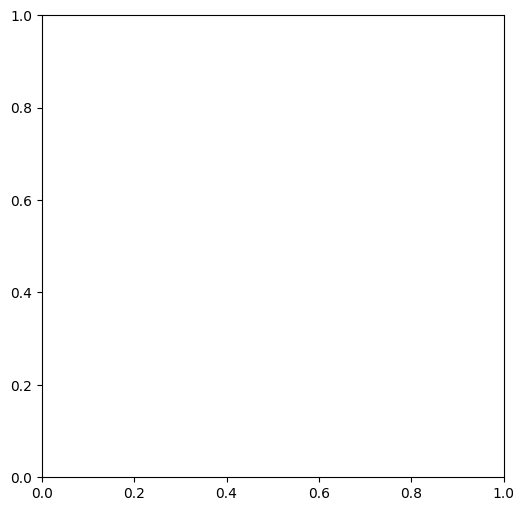

In [19]:
# ============================================================
# PIE TESTING EXPORT CELL
# - one chart per direct parameter setting
# - one chart per helper-behavior case
# - saves into: generated/pie_testing
# ============================================================

from pathlib import Path
from datetime import datetime
from uuid import uuid4
import shutil
import re
import json
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
TEST_LIBRARIES = ["matplotlib", "seaborn", "altair", "plotly"]   # e.g. ["matplotlib"] or ["matplotlib", "altair", "plotly"]
CLEAR_PIE_TESTING = True
PIE_TESTING_ROOT = PROJECT / "testing" / "pie_testing"

# If True: use only unique canonical values per parameter.
# Example: if two raw codes both map to "none", only one chart is created for "none".
UNIQUE_CANONICAL_VALUES_ONLY = True

# ------------------------------------------------------------
# DELETE OLD DATA
# ------------------------------------------------------------

shutil.rmtree(PIE_TESTING_ROOT, ignore_errors=True)

# ------------------------------------------------------------
# FIXED TEST DATASETS
# These are chosen to make helper-driven behaviors visible.
# ------------------------------------------------------------
CATEGORY_COL = "category"
VALUE_COL = "value"

DF_STANDARD = pd.DataFrame({
    CATEGORY_COL: ["A", "B", "C", "D", "E"],
    VALUE_COL:    [35, 25, 18, 12, 10],
})

DF_LONG_LABELS = pd.DataFrame({
    CATEGORY_COL: [
        "Very long category alpha",
        "Very long category beta",
        "Very long category gamma",
        "Very long category delta",
        "Very long category epsilon",
    ],
    VALUE_COL: [42, 24, 16, 10, 8],
})

DF_CROWDED = pd.DataFrame({
    CATEGORY_COL: ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    VALUE_COL:    [26, 18, 14, 11, 9, 7, 5, 4, 3, 3],
})

DF_SMALL_SLICES = pd.DataFrame({
    CATEGORY_COL: ["A", "B", "C", "D", "E", "F", "G"],
    VALUE_COL:    [55, 14, 10, 8, 6, 4, 3],
})

TEST_DATASETS = {
    "standard": DF_STANDARD,
    "long_labels": DF_LONG_LABELS,
    "crowded": DF_CROWDED,
    "small_slices": DF_SMALL_SLICES,
}

# ------------------------------------------------------------
# BASE STYLE
# This is the default visible baseline used before overriding
# one tested setting at a time.
# ------------------------------------------------------------
BASE_STYLE = harmonize_style({
    key: spec["default"] for key, spec in STYLE_SPEC.items()
} | {
    "title_present": True,
    "title_location": "center",
    "title_color": "black",
    "title_size": "medium",
    "subtitle_present": True,
    "legend_present": True,
    "legend_title_size": "small",
    "legend_title_color": "black",
    "legend_text_color": "black",
    "legend_outline": False,
    "legend_fill": "none",
    "legend_orientation": "right",
    "slice_text_present": True,
    "slice_text_content": "percent",
    "slice_text_orientation": "horizontal",
    "label_placement": "inside",
    "label_text_color": "adaptive",
    "percentage_format": "integer",
    "slice_border_width": 1,
    "slice_border_color": "white",
    "outline_chart": False,
    "image_outline": False,
    "background": "white",
    "palette_type": "bright_multicolor",
    "sort_order": "descending",
    "slice_count": 5,
})

# ------------------------------------------------------------
# SMALL HELPERS
# ------------------------------------------------------------
def ensure_pie_testing_dirs(out_root: Path, clear_output: bool = True) -> None:
    if clear_output and out_root.exists():
        shutil.rmtree(out_root)

    for sub in SUBDIRS:
        for lib in LIBRARIES:
            (out_root / sub / lib).mkdir(parents=True, exist_ok=True)


def sanitize_slug(text) -> str:
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9._-]+", "_", text)
    return text.strip("_").lower()


def new_test_chart_id(case_type: str, case_name: str, library: str) -> str:
    return f"pie_test_{sanitize_slug(case_type)}_{sanitize_slug(case_name)}_{sanitize_slug(library)}_{uuid4().hex[:8]}"


def get_unique_param_values(param_name: str):
    spec = STYLE_SPEC[param_name]

    if param_name == "slice_count":
        return list(sorted(DEFAULT_PARAM_COUNTS["slice_count"].keys()))

    values = list(spec["codes"].values())

    if UNIQUE_CANONICAL_VALUES_ONLY:
        seen = []
        for v in values:
            if v not in seen:
                seen.append(v)
        values = seen

    return values


def make_style_ready_for_param(base_style: dict, param_name: str) -> dict:
    """
    Turns on nearby supporting settings so the tested parameter
    is actually visible in the exported chart.
    """
    style = dict(base_style)

    # Title-related
    if param_name in {"title_present", "title_location", "title_color", "title_size", "subtitle_present"}:
        style["title_present"] = True
        style["title_location"] = "center"
        style["subtitle_present"] = True

    # Legend-related
    if param_name in {
        "legend_present", "legend_title_size", "legend_title_color",
        "legend_text_color", "legend_outline", "legend_fill", "legend_orientation"
    }:
        style["legend_present"] = True
        style["legend_orientation"] = "right"
        style["legend_title_size"] = "small"
        style["legend_title_color"] = "black"
        style["legend_text_color"] = "black"

    # Slice text / labels
    if param_name in {
        "slice_text_present", "slice_text_content", "slice_text_orientation",
        "label_placement", "label_text_color", "percentage_format"
    }:
        style["slice_text_present"] = True
        style["slice_text_content"] = "percent"
        style["slice_text_orientation"] = "horizontal"
        style["label_placement"] = "inside"
        style["label_text_color"] = "adaptive"
        style["percentage_format"] = "integer"

    # Border visibility
    if param_name == "slice_border_color":
        style["slice_border_width"] = 2
    if param_name == "slice_border_width":
        style["slice_border_color"] = "black"

    return style


def make_plot_df_for_style(source_df: pd.DataFrame, style: dict) -> pd.DataFrame:
    visible_slice_count = int(style.get("slice_count", 5))
    s = cap_visible_slices(source_df.set_index(CATEGORY_COL)[VALUE_COL], visible_slice_count)
    if s is None:
        return source_df.copy()
    return s.rename_axis(CATEGORY_COL).reset_index(name=VALUE_COL)


def save_case(
    library: str,
    plot_df: pd.DataFrame,
    style: dict,
    title: str,
    out_root: Path,
    case_type: str,
    case_name: str,
    dataset_name: str,
):
    rng = np.random.default_rng(42)
    chart_id = new_test_chart_id(case_type=case_type, case_name=case_name, library=library)

    image_dir = out_root / "images" / library
    table_dir = out_root / "tables" / library
    meta_dir = out_root / "meta" / library

    table_path = table_dir / f"{chart_id}.csv"
    meta_path = meta_dir / f"{chart_id}.json"

    plot_df.to_csv(table_path, index=False)

    if library == "altair":
        image_path = image_dir / f"{chart_id}.svg"
        chart = render_pie_altair(
            plot_df=plot_df,
            category_col=CATEGORY_COL,
            value_col=VALUE_COL,
            title=title,
            style=style,
            rng=rng,
        )
        save_altair_svg(chart, image_path)

    elif library == "matplotlib":
        image_path = image_dir / f"{chart_id}.png"
        fig = render_pie_matplotlib(
            plot_df=plot_df,
            category_col=CATEGORY_COL,
            value_col=VALUE_COL,
            title=title,
            style=style,
            rng=rng,
        )
        save_matplotlib_png(fig, image_path)

    elif library == "seaborn":
        image_path = image_dir / f"{chart_id}.png"
        fig = render_pie_seaborn(
            plot_df=plot_df,
            category_col=CATEGORY_COL,
            value_col=VALUE_COL,
            title=title,
            style=style,
            rng=rng,
        )
        save_matplotlib_png(fig, image_path)

    elif library == "plotly":
        image_path = image_dir / f"{chart_id}.png"
        fig = render_pie_plotly(
            plot_df=plot_df,
            category_col=CATEGORY_COL,
            value_col=VALUE_COL,
            title=title,
            style=style,
            rng=rng,
        )
        save_plotly_png(fig, image_path)

    else:
        raise ValueError(f"Unsupported library: {library}")

    meta = {
        "chart_id": chart_id,
        "chart_type": "pie",
        "library": library,
        "dataset_source": "pie_testing",
        "image_path": str(image_path),
        "table_path": str(table_path),
        "data_context": {
            "category_col": CATEGORY_COL,
            "value_col": VALUE_COL,
            "row_count": int(len(plot_df)),
            "dataset_name": dataset_name,
            "case_type": case_type,
            "case_name": case_name,
        },
        "style": style,
        "created_utc": datetime.utcnow().isoformat() + "Z",
    }
    save_metadata(meta, meta_path)
    return meta


# ------------------------------------------------------------
# DIRECT PARAMETER CASES
# One chart per parameter value defined in code.
# This uses STYLE_SPEC / DEFAULT_PARAM_COUNTS from the code,
# not the Excel sheet.
# ------------------------------------------------------------
def build_direct_parameter_cases():
    cases = []

    for param_name in STYLE_SPEC.keys():
        for value in get_unique_param_values(param_name):
            style = make_style_ready_for_param(BASE_STYLE, param_name)
            style[param_name] = value

            # Choose dataset that best shows that parameter
            if param_name in {"label_placement", "slice_text_content", "slice_text_orientation", "label_text_color", "percentage_format"}:
                dataset_name = "long_labels"
            elif param_name in {"slice_count"}:
                dataset_name = "crowded"
            elif param_name in {"sort_order"}:
                dataset_name = "small_slices"
            else:
                dataset_name = "standard"

            cases.append({
                "case_type": "parameter",
                "case_name": f"{param_name}__{value}",
                "dataset_name": dataset_name,
                "title": f"{param_name}: {value}",
                "style": harmonize_style(style),
            })

    return cases


# ------------------------------------------------------------
# HELPER-BEHAVIOR CASES
# These are explicit cases to trigger helper-driven output paths,
# rather than just a simple one-parameter setting.
# ------------------------------------------------------------
HELPER_BEHAVIOR_CASES = [
    # build_label_plan / content-layout behaviors
    {
        "case_type": "helper",
        "case_name": "content_percent_box",
        "dataset_name": "standard",
        "title": "Helper: percent_box",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "percent_box",
            "label_placement": "inside",
            "label_text_color": "white_on_black_box",
        },
    },
    {
        "case_type": "helper",
        "case_name": "content_percent_inside_label_outside",
        "dataset_name": "long_labels",
        "title": "Helper: percent inside, label outside",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "percent_inside_label_outside",
            "label_placement": "split_label_outside_percent_inside",
            "slice_text_orientation": "horizontal",
        },
    },
    {
        "case_type": "helper",
        "case_name": "label_fit_inside_else_outside",
        "dataset_name": "long_labels",
        "title": "Helper: fit inside else outside",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "label_percent_stacked",
            "label_placement": "fit_inside_else_outside",
        },
    },
    {
        "case_type": "helper",
        "case_name": "label_outside_with_leader_lines",
        "dataset_name": "long_labels",
        "title": "Helper: outside with leader lines",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "label",
            "label_placement": "outside_with_leader_lines",
        },
    },
    {
        "case_type": "helper",
        "case_name": "split_label_outside_value_inside",
        "dataset_name": "long_labels",
        "title": "Helper: label outside, value inside",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "value",
            "label_placement": "split_label_outside_with_leader_lines_value_inside",
        },
    },

    # text-color helper behaviors
    {
        "case_type": "helper",
        "case_name": "label_text_adaptive",
        "dataset_name": "standard",
        "title": "Helper: adaptive text color",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "percent",
            "label_placement": "inside",
            "label_text_color": "adaptive",
            "palette_type": "dark_palette",
        },
    },
    {
        "case_type": "helper",
        "case_name": "label_text_outside_black_inside_white",
        "dataset_name": "long_labels",
        "title": "Helper: outside black, inside white",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "percent_inside_label_outside",
            "label_placement": "split_label_outside_percent_inside",
            "label_text_color": "outside_black_inside_white",
        },
    },
    {
        "case_type": "helper",
        "case_name": "label_text_adaptive_category_black",
        "dataset_name": "long_labels",
        "title": "Helper: adaptive category black",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "percent_inside_label_outside",
            "label_placement": "split_label_outside_percent_inside",
            "label_text_color": "adaptive_category_black",
        },
    },

    # sorting / palette / background visible helper paths
    {
        "case_type": "helper",
        "case_name": "sort_ascending",
        "dataset_name": "small_slices",
        "title": "Helper: ascending sort",
        "style_overrides": {
            "sort_order": "ascending",
            "slice_text_present": True,
            "slice_text_content": "value",
        },
    },
    {
        "case_type": "helper",
        "case_name": "sort_descending",
        "dataset_name": "small_slices",
        "title": "Helper: descending sort",
        "style_overrides": {
            "sort_order": "descending",
            "slice_text_present": True,
            "slice_text_content": "value",
        },
    },
    {
        "case_type": "helper",
        "case_name": "palette_rainbow_ordered",
        "dataset_name": "crowded",
        "title": "Helper: rainbow ordered palette",
        "style_overrides": {
            "palette_type": "rainbow_ordered",
            "slice_text_present": False,
        },
    },
    {
        "case_type": "helper",
        "case_name": "palette_one_color",
        "dataset_name": "standard",
        "title": "Helper: one-color palette",
        "style_overrides": {
            "palette_type": "one_color",
        },
    },
    {
        "case_type": "helper",
        "case_name": "background_transparent",
        "dataset_name": "standard",
        "title": "Helper: transparent background",
        "style_overrides": {
            "background": "transparent",
            "image_outline": True,
        },
    },

    # sanitize-style behaviors: explicit cases that often trigger fallback logic
    {
        "case_type": "helper",
        "case_name": "sanitize_crowded_labels",
        "dataset_name": "crowded",
        "title": "Helper: crowded label sanitization",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "label_value_percent_inline",
            "label_placement": "inside",
            "slice_text_orientation": "mixed",
        },
    },
    {
        "case_type": "helper",
        "case_name": "sanitize_crowded_outside_labels",
        "dataset_name": "crowded",
        "title": "Helper: crowded outside labels",
        "style_overrides": {
            "slice_text_present": True,
            "slice_text_content": "label_percent_stacked",
            "label_placement": "outside_with_leader_lines",
        },
    },
]

def build_helper_cases():
    cases = []
    for spec in HELPER_BEHAVIOR_CASES:
        style = dict(BASE_STYLE)
        style.update(spec["style_overrides"])
        cases.append({
            "case_type": spec["case_type"],
            "case_name": spec["case_name"],
            "dataset_name": spec["dataset_name"],
            "title": spec["title"],
            "style": harmonize_style(style),
        })
    return cases


# ------------------------------------------------------------
# MAIN RUNNER
# ------------------------------------------------------------
def run_pie_testing_export(test_libraries=TEST_LIBRARIES, out_root=PIE_TESTING_ROOT, clear_output=True):
    ensure_pie_testing_dirs(out_root, clear_output=clear_output)

    direct_cases = build_direct_parameter_cases()
    helper_cases = build_helper_cases()
    all_cases = direct_cases + helper_cases

    all_meta = []

    for library in test_libraries:
        for case in all_cases:
            source_df = TEST_DATASETS[case["dataset_name"]]
            style = harmonize_style(case["style"])
            plot_df = make_plot_df_for_style(source_df, style)

            try:
                meta = save_case(
                    library=library,
                    plot_df=plot_df,
                    style=style,
                    title=case["title"],
                    out_root=out_root,
                    case_type=case["case_type"],
                    case_name=case["case_name"],
                    dataset_name=case["dataset_name"],
                )
                all_meta.append(meta)
            except Exception as e:
                all_meta.append({
                    "chart_id": None,
                    "chart_type": "pie",
                    "library": library,
                    "dataset_source": "pie_testing",
                    "image_path": None,
                    "table_path": None,
                    "data_context": {
                        "case_type": case["case_type"],
                        "case_name": case["case_name"],
                        "dataset_name": case["dataset_name"],
                        "error": f"{type(e).__name__}: {e}",
                    },
                    "style": style,
                    "created_utc": datetime.utcnow().isoformat() + "Z",
                })

    manifest_df = pd.DataFrame([
        {
            "chart_id": m.get("chart_id"),
            "library": m.get("library"),
            "case_type": m.get("data_context", {}).get("case_type"),
            "case_name": m.get("data_context", {}).get("case_name"),
            "dataset_name": m.get("data_context", {}).get("dataset_name"),
            "image_path": m.get("image_path"),
            "table_path": m.get("table_path"),
            "error": m.get("data_context", {}).get("error"),
        }
        for m in all_meta
    ])

    manifest_path = out_root / "manifest_all_cases.csv"
    manifest_df.to_csv(manifest_path, index=False)

    print(f"Saved pie testing outputs to: {out_root}")
    print(f"Manifest: {manifest_path}")
    print(f"Total cases attempted: {len(all_cases) * len(test_libraries)}")
    print(f"Direct parameter cases: {len(direct_cases)}")
    print(f"Helper-behavior cases: {len(helper_cases)}")

    return all_meta, manifest_df


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
all_meta, manifest_df = run_pie_testing_export(
    test_libraries=TEST_LIBRARIES,
    out_root=PIE_TESTING_ROOT,
    clear_output=CLEAR_PIE_TESTING,
)

manifest_df.head(20)